In [55]:
import warnings
warnings.filterwarnings("ignore")
import pandas as P
import numpy as NUM
import matplotlib.pyplot as PLOT
import seaborn as SEA

In [56]:
D = P.read_csv ("EVP.csv")

In [57]:
print(D.columns)
print("\n")
print(D.shape)

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Legislative District', 'DOL Vehicle ID', 'Vehicle Location',
       'Electric Utility', '2020 Census Tract'],
      dtype='object')


(280833, 16)


In [58]:
print(D.dtypes)

VIN (1-10)                                            object
County                                                object
City                                                  object
State                                                 object
Postal Code                                          float64
Model Year                                             int64
Make                                                  object
Model                                                 object
Electric Vehicle Type                                 object
Clean Alternative Fuel Vehicle (CAFV) Eligibility     object
Electric Range                                       float64
Legislative District                                 float64
DOL Vehicle ID                                         int64
Vehicle Location                                      object
Electric Utility                                      object
2020 Census Tract                                    float64
dtype: object


In [59]:
from sklearn.preprocessing import LabelEncoder

In [60]:
D["County"] = D[["County"]].apply(LabelEncoder().fit_transform)
D["State"] = D[["State"]].apply(LabelEncoder().fit_transform)
D["City"] = D[["City"]].apply(LabelEncoder().fit_transform)
D["Make"] = D[["Make"]].apply(LabelEncoder().fit_transform)
D["Model"] = D[["Model"]].apply(LabelEncoder().fit_transform)
D["Electric Vehicle Type"] = D[["Electric Vehicle Type"]].apply(LabelEncoder().fit_transform)
D["Clean Alternative Fuel Vehicle (CAFV) Eligibility"] = D[["Clean Alternative Fuel Vehicle (CAFV) Eligibility"]].apply(LabelEncoder().fit_transform)
D["Electric Utility"] = D[["Electric Utility"]].apply(LabelEncoder().fit_transform)

In [61]:
print(D.dtypes)

VIN (1-10)                                            object
County                                                 int64
City                                                   int64
State                                                  int64
Postal Code                                          float64
Model Year                                             int64
Make                                                   int64
Model                                                  int64
Electric Vehicle Type                                  int64
Clean Alternative Fuel Vehicle (CAFV) Eligibility      int64
Electric Range                                       float64
Legislative District                                 float64
DOL Vehicle ID                                         int64
Vehicle Location                                      object
Electric Utility                                       int64
2020 Census Tract                                    float64
dtype: object


In [62]:
NULL_Y = D["Electric Range"].isnull ().sum ()
print(NULL_Y)

12


In [63]:
D["Electric Range"] = D["Electric Range"].fillna (D["Electric Range"].mean ())

In [64]:
NULL_X = X.isnull ().sum ()
print(NULL_X)

County                                               0
City                                                 0
State                                                0
Postal Code                                          0
Model Year                                           0
Make                                                 0
Model                                                0
Electric Vehicle Type                                0
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0
Legislative District                                 0
Electric Utility                                     0
dtype: int64


In [65]:
D["Postal Code"] = D["Postal Code"].fillna (D["Postal Code"].mean ())
D["Legislative District"] = D["Legislative District"].fillna (D["Legislative District"].mean ())

In [66]:
X = D.drop (["VIN (1-10)" , "2020 Census Tract" , "DOL Vehicle ID" , "Electric Range" , "Vehicle Location"] , axis = 1)
Y = D["Electric Range"]

In [67]:
from sklearn.model_selection import train_test_split

In [68]:
X_Train , X_Test , Y_Train , Y_Test = train_test_split (X , Y , test_size = 0.2 , random_state = 42)
print(X_Train.shape)
print(X_Test.shape)
print(Y_Train.shape)
print(Y_Test.shape)

(224666, 11)
(56167, 11)
(224666,)
(56167,)


In [69]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

In [70]:
M_1 = RandomForestRegressor ()
F_1 = M_1.fit (X_Train , Y_Train)
M_2 = LinearRegression ()
F_2 = M_2.fit (X_Train , Y_Train)

In [71]:
from sklearn.metrics import r2_score , mean_squared_error , mean_absolute_error

In [72]:
PRE_1 = F_1.predict (X_Test)
print(PRE_1)
PRE_2 = F_2.predict (X_Test)
print(PRE_2)

[ 42.   0.   0. ... 208.   0. 259.]
[ 59.94493637  30.84590266  19.98713346 ... 187.6336363   -0.8262158
 123.16769133]


In [73]:
R2_1 = r2_score (Y_Test , PRE_1)
print(R2_1 * 100 , "%")
MSE_1 = mean_squared_error (Y_Test , PRE_1)
print(MSE_1)
MAE_1 = mean_absolute_error (Y_Test , PRE_1)
print(MAE_1)
RMSE_1 = NUM.sqrt (MSE_1)
print(RMSE_1)
print("\n")
R2_2 = r2_score (Y_Test , PRE_2)
print(R2_2 * 100 , "%")
MSE_2 = mean_squared_error (Y_Test , PRE_2)
print(MSE_2)
MAE_2 = mean_absolute_error (Y_Test , PRE_2)
print(MAE_2)
RMSE_2 = NUM.sqrt (MSE_2)
print(RMSE_2)

99.80184704748638 %
12.141521075765551
0.3831745312423359
3.4844685499750963


54.147087233435556 %
2809.5675571738448
36.650020913076865
53.00535404252899


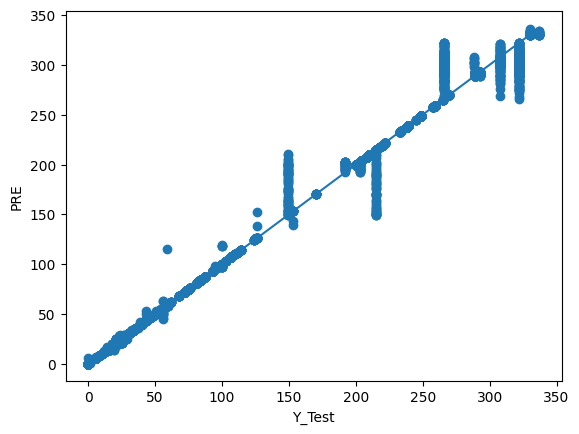

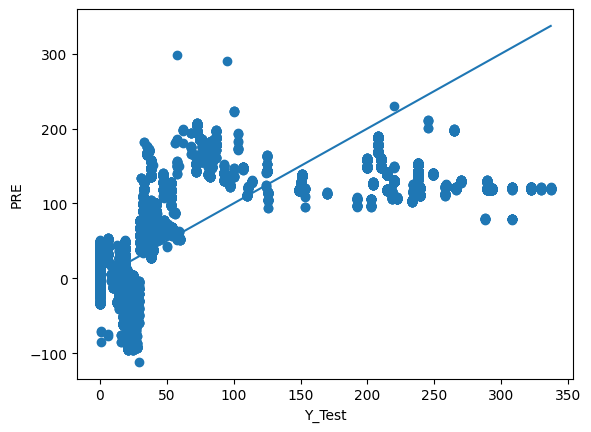

In [74]:
PLOT.scatter (Y_Test , PRE_1)
PLOT.plot ([Y_Test.min () , Y_Test.max ()] , [Y_Test.min () , Y_Test.max ()])
PLOT.xlabel ("Y_Test")
PLOT.ylabel ("PRE")
PLOT.show ()
print("\n")
PLOT.scatter (Y_Test , PRE_2)
PLOT.plot ([Y_Test.min () , Y_Test.max ()] , [Y_Test.min () , Y_Test.max ()])
PLOT.xlabel ("Y_Test")
PLOT.ylabel ("PRE")
PLOT.show ()

In [75]:
print(D.columns)

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Legislative District', 'DOL Vehicle ID', 'Vehicle Location',
       'Electric Utility', '2020 Census Tract'],
      dtype='object')


In [76]:
print(D.dtypes)

VIN (1-10)                                            object
County                                                 int64
City                                                   int64
State                                                  int64
Postal Code                                          float64
Model Year                                             int64
Make                                                   int64
Model                                                  int64
Electric Vehicle Type                                  int64
Clean Alternative Fuel Vehicle (CAFV) Eligibility      int64
Electric Range                                       float64
Legislative District                                 float64
DOL Vehicle ID                                         int64
Vehicle Location                                      object
Electric Utility                                       int64
2020 Census Tract                                    float64
dtype: object


In [77]:
PRE_T_1 = F_1.predict ([[1 , 5 , 2 , 98101.0 , 2020 , 3 , 10 , 1 , 2 , 4 , 43.0]])
print(PRE_T_1)
PRE_T_2 = F_2.predict ([[1 , 5 , 2 , 98101.0 , 2020 , 3 , 10 , 1 , 2 , 4 , 43.0]])
print(PRE_T_2)

[16.84]
[-17.77067334]
